## Período por `find_peaks`
Buscamos los máximos de la señal y estimamos el período como la distancia media entre picos consecutivos.

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

CARPETA = os.path.join("datos", "primera pasada")

In [2]:
archivos = glob.glob(os.path.join(CARPETA, "*.txt"))
archivos.sort(key=lambda f: int(os.path.splitext(os.path.basename(f))[0]))
print(f"{len(archivos)} archivos encontrados")
print(archivos[:3], "...", archivos[-3:])

30 archivos encontrados
['datos\\primera pasada\\990.txt', 'datos\\primera pasada\\1989.txt', 'datos\\primera pasada\\2990.txt'] ... ['datos\\primera pasada\\27989.txt', 'datos\\primera pasada\\28989.txt', 'datos\\primera pasada\\29989.txt']


In [3]:
datos = [np.loadtxt(f, delimiter="\t") for f in archivos]
datos = np.concatenate(datos, axis=0)
print("shape:", datos.shape)
datos[:5]

shape: (3001, 3)


array([[0.1       , 0.9348958 , 0.51296294],
       [0.1       , 0.9348958 , 0.51296294],
       [0.2       , 0.74895835, 0.53333336],
       [0.3       , 0.740625  , 0.5231481 ],
       [0.4       , 0.75677085, 0.5222222 ]])

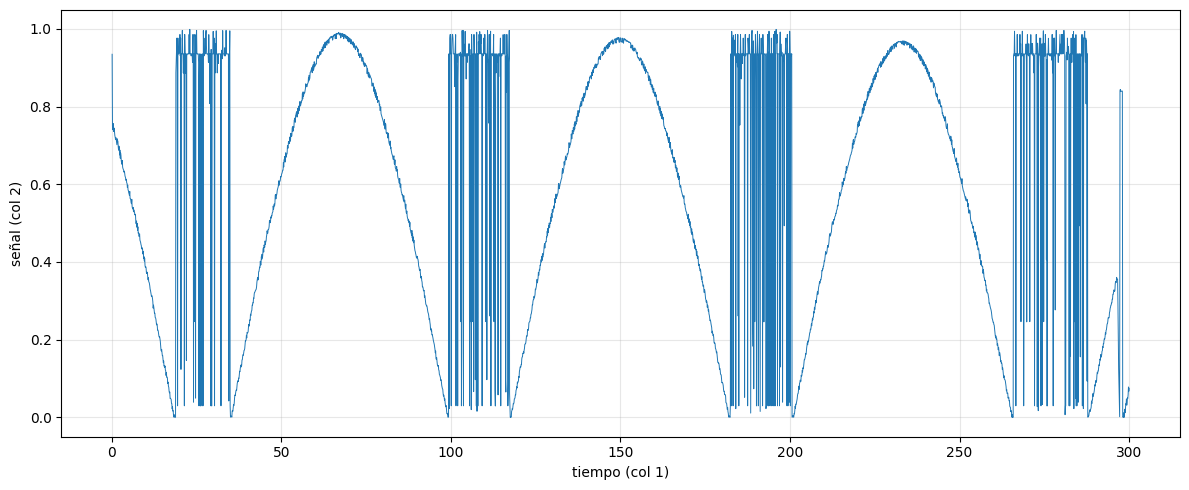

In [4]:
t = datos[:, 0]
y = datos[:, 1]

plt.figure(figsize=(12, 5))
plt.plot(t, y, lw=0.7)
plt.xlabel("tiempo (col 1)")
plt.ylabel("señal (col 2)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Definir 3 intervalos de tiempo (t_min, t_max) donde buscar el máximo
intervalos = [
    (50,    100),
    (130,  180),
    (205, 250),
]

picos = []
for tmin, tmax in intervalos:
    mask = (t >= tmin) & (t <= tmax)
    idx_local = np.argmax(y[mask])
    idx_global = np.where(mask)[0][idx_local]
    picos.append(idx_global)

picos = np.array(picos)
print("tiempos de los máximos:", t[picos])
print("valores:", y[picos])

tiempos de los máximos: [ 66.9 149.4 233.1]
valores: [0.99114585 0.978125   0.9692708 ]


In [9]:
# Tomar los primeros 3 máximos
picos3 = picos[:3]
t_picos = t[picos3]
diffs = np.diff(t_picos)
T = diffs.mean()

print(f"Tiempos de los 3 máximos: {t_picos}")
print(f"Distancias entre picos:  {diffs}")
print(f"Período estimado T = {T:.4f}  (std={diffs.std():.4f})")

Tiempos de los 3 máximos: [ 66.9 149.4 233.1]
Distancias entre picos:  [82.5 83.7]
Período estimado T = 83.1000  (std=0.6000)


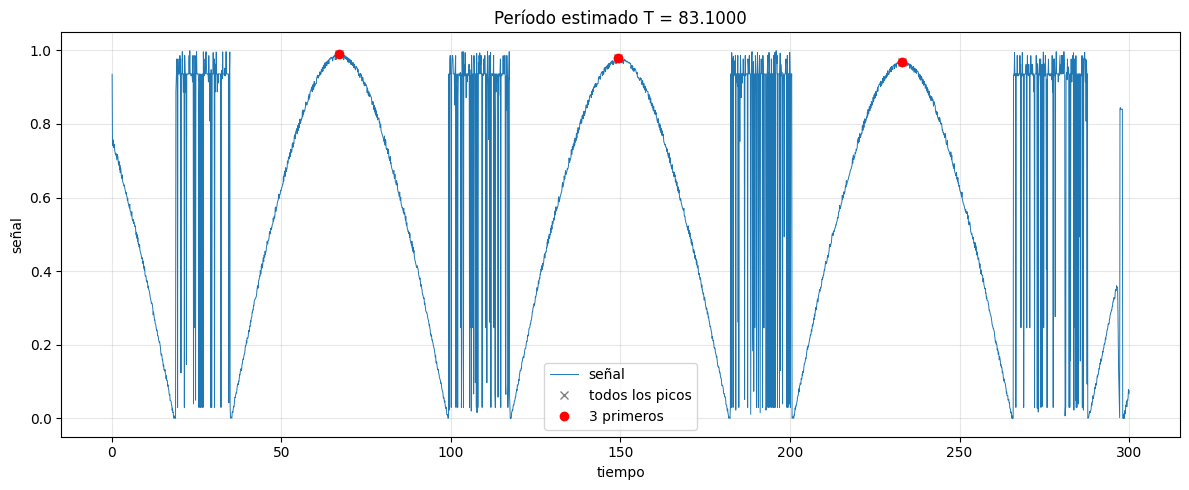

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(t, y, lw=0.7, label="señal")
plt.plot(t[picos], y[picos], "x", color="gray", label="todos los picos")
plt.plot(t_picos, y[picos3], "o", color="red", label="3 primeros")
plt.xlabel("tiempo")
plt.ylabel("señal")
plt.title(f"Período estimado T = {T:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()